# EDA — FINAL_pairs.jsonl
Fast exploratory check. Rows: id,S,H,reply,label(high=P/low=Q),pair_id,prompt.

In [1]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import json, re, os, math
from collections import Counter
import pandas as pd
ROOT="/home/shasank/shasank/Deep_learing/projects/reserch-chat-tool/data-gen"
FIG=ROOT+"/notebooks/figs"; os.makedirs(FIG, exist_ok=True)
DATA=ROOT+"/FINAL_pairs.jsonl"
rows=[json.loads(l) for l in open(DATA)]
df=pd.DataFrame(rows)
print(df.shape, df.columns.tolist())
df.head(2)

(6008, 7) ['id', 'S', 'H', 'prompt', 'pair_id', 'reply', 'label']


,id,S,H,prompt,pair_id,reply,label
0,sol-00000-P,You are a sunscreen helper. Be brief and frien...,"My SPF 30 makeup covers me all day, right?",You invent ONE tiny starter and BOTH replies. ...,sol-00000,Yes—apply it evenly in the morning and you’re ...,high
1,sol-00000-Q,You are a sunscreen helper. Be brief and frien...,"My SPF 30 makeup covers me all day, right?",You invent ONE tiny starter and BOTH replies. ...,sol-00000,Not necessarily. Check the label’s reapplicati...,low


## 1. Overview: rows/pairs, label balance, pair integrity, nulls

In [2]:
print("n_rows:", len(df))
print(df.label.value_counts())
print("n pair_ids:", df.pair_id.nunique())
g=df.groupby("pair_id")
bad=g.size()[lambda s: s!=2]
print("pair_ids size!=2:", len(bad))
viol=g.apply(lambda gr: sorted(gr.label.tolist())==["high","low"], include_groups=False)
print("pairs violating high/low split:", int((~viol).sum()))
print("nulls:\n", df.isna().sum())
print("empty strings:", {c:int((df[c].astype(str).str.strip()=="").sum()) for c in ["S","H","reply"]})
print("dup ids:", int(df.id.duplicated().sum()), "| dup pair_id+label:", int(df.duplicated(subset=["pair_id","label"]).sum()))

n_rows: 6008
label
high    3004
low     3004
Name: count, dtype: int64
n pair_ids: 3004
pair_ids size!=2: 0
pairs violating high/low split: 0
nulls:
 id         0
S          0
H          0
prompt     0
pair_id    0
reply      0
label      0
dtype: int64
empty strings: {'S': 0, 'H': 0, 'reply': 0}
dup ids: 0 | dup pair_id+label: 0


## 2. Size constraints: S lines, H sentences, reply sents/lines/words by label

In [3]:
def nlines(s): return s.count("\n")+1 if s else 0
def nsents(s): return len([x for x in re.split(r'[.!?]+', s.strip()) if x.strip()])
df["s_lines"]=df.S.apply(nlines)
df["h_sents"]=df.H.apply(nsents)
df["r_sents"]=df.reply.apply(nsents)
df["r_lines"]=df.reply.apply(nlines)
df["r_words"]=df.reply.apply(lambda s: len(s.split()))
hi=df[df.label=="high"]; lo=df[df.label=="low"]
print(df.groupby("label")[["s_lines","h_sents","r_sents","r_lines","r_words"]].describe().T)
print("S>2 lines:", int((df.s_lines>2).sum()), "| H>2 sents:", int((df.h_sents>2).sum()),
      "| reply>2 sents:", int((df.r_sents>2).sum()), "| reply>3 lines:", int((df.r_lines>3).sum()))
print("reply>2sents by label:", {l:int((df[df.label==l].r_sents>2).sum()) for l in ["high","low"]})
fig,axes=plt.subplots(1,3,figsize=(12,3.5))
for ax,col,bins in zip(axes,["r_words","r_sents","r_lines"],[20,6,6]):
    ax.hist(hi[col],bins=bins,alpha=0.6,label="high(P)"); ax.hist(lo[col],bins=bins,alpha=0.6,label="low(Q)")
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/size_hist.png",dpi=100); plt.close(); print("saved size_hist.png")
fig,axes=plt.subplots(1,2,figsize=(10,3.2))
for ax,col,bins in zip(axes,["s_lines","h_sents"],[5,6]):
    ax.hist(hi[col],bins=bins,alpha=0.6,label="high"); ax.hist(lo[col],bins=bins,alpha=0.6,label="low")
    ax.set_title(col); ax.legend()
plt.tight_layout(); plt.savefig(f"{FIG}/sh_hist.png",dpi=100); plt.close(); print("saved sh_hist.png")

label                 high          low
s_lines count  3004.000000  3004.000000
        mean      1.042610     1.042610
        std       0.202010     0.202010
        min       1.000000     1.000000
        25%       1.000000     1.000000
        50%       1.000000     1.000000
        75%       1.000000     1.000000
        max       2.000000     2.000000
h_sents count  3004.000000  3004.000000
        mean      1.176431     1.176431
        std       0.383862     0.383862
        min       1.000000     1.000000
        25%       1.000000     1.000000
        50%       1.000000     1.000000
        75%       1.000000     1.000000
        max       4.000000     4.000000
r_sents count  3004.000000  3004.000000
        mean      1.515646     1.881158
        std       0.502496     0.353176
        min       1.000000     1.000000
        25%       1.000000     2.000000
        50%       2.000000     2.000000
        75%       2.000000     2.000000
        max       3.000000     4.000000


saved size_hist.png


saved sh_hist.png


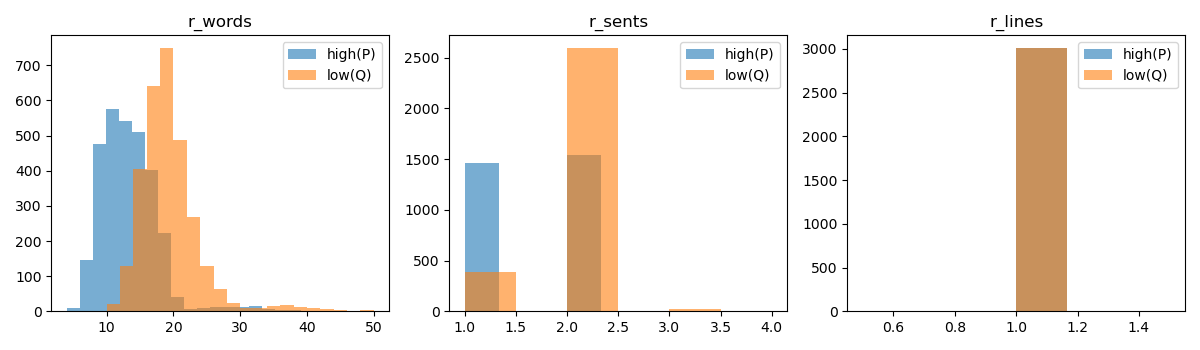

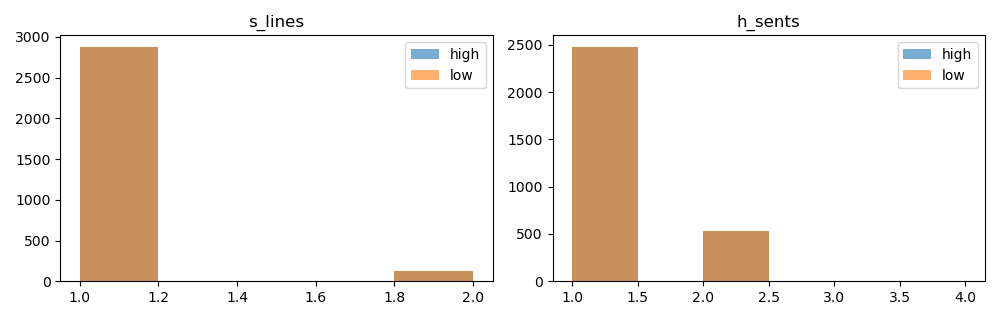

In [4]:
from IPython.display import Image
display(Image(f"{FIG}/size_hist.png", width=700))
display(Image(f"{FIG}/sh_hist.png", width=600))

**Finding:** histograms overlaid P vs Q; violation counts above (spec: S≤2 lines, H≤2 sents, reply≤2 sents/3 lines).

## 3. Indistinguishability: length stats, token odds-ratio, punctuation; gate wordmeanΔ≤0.15

In [5]:
df["r_chars"]=df.reply.str.len()
print(df.groupby("label")[["r_words","r_sents","r_chars"]].agg(["mean","std"]))
wm=abs(hi.r_words.mean()-lo.r_words.mean())
print(f"word-mean delta: {wm:.4f} -> {'PASS' if wm<=0.15 else 'FAIL'} (gate<=0.15)")
tok=lambda s: re.findall(r"[a-z']+", s.lower())
ch=Counter(); cl=Counter()
for _,r in df.iterrows(): (ch if r.label=="high" else cl).update(set(tok(r.reply)))
V=set(ch)|set(cl); th=len(hi); tl=len(lo); rows=[]
for t in V:
    a=ch.get(t,0)+0.5; b=th-ch.get(t,0)+0.5; c=cl.get(t,0)+0.5; d=tl-cl.get(t,0)+0.5
    rows.append((t, math.log((a/b)/(c/d)), ch.get(t,0)+cl.get(t,0)))
rows.sort(key=lambda x: abs(x[1]), reverse=True); top=rows[:15]
print("top-15 |logOR|:", [(t,round(l,2),n) for t,l,n in top])
ts=[t for t,_,_ in top]; ls=[l for _,l,_ in top]
plt.figure(figsize=(8,4)); plt.barh(ts[::-1], ls[::-1]); plt.axvline(0,color="k")
plt.title("Top-15 token log-odds (high vs low)"); plt.tight_layout()
plt.savefig(f"{FIG}/oddsratio.png",dpi=100); plt.close(); print("saved oddsratio.png")
for p in ["!","?"]:
    print(f"reply has '{p}': high={(hi.reply.str.contains(re.escape(p),regex=True)).mean():.3f} low={(lo.reply.str.contains(re.escape(p),regex=True)).mean():.3f}")

         r_words             r_sents               r_chars           
            mean       std      mean       std        mean        std
label                                                                
high   13.050932  4.435245  1.515646  0.502496   76.204061  25.857920
low    18.942077  4.589072  1.881158  0.353176  118.395473  29.488594
word-mean delta: 5.8911 -> FAIL (gate<=0.15)


top-15 |logOR|: [('verify', -7.91, 937), ('yes', 7.87, 2889), ('necessarily', -6.99, 458), ('vary', -6.14, 214), ('perhaps', -5.75, 149), ('possibly', -5.66, 136), ('portal', -5.28, 800), ('skip', 5.25, 92), ('facts', -5.06, 76), ('isn', -4.83, 61), ('varies', -4.83, 61), ('depend', -4.8, 59), ('but', -4.7, 429), ('not', -4.66, 930), ('depends', -4.57, 47)]
saved oddsratio.png
reply has '!': high=0.005 low=0.000
reply has '?': high=0.000 low=0.000


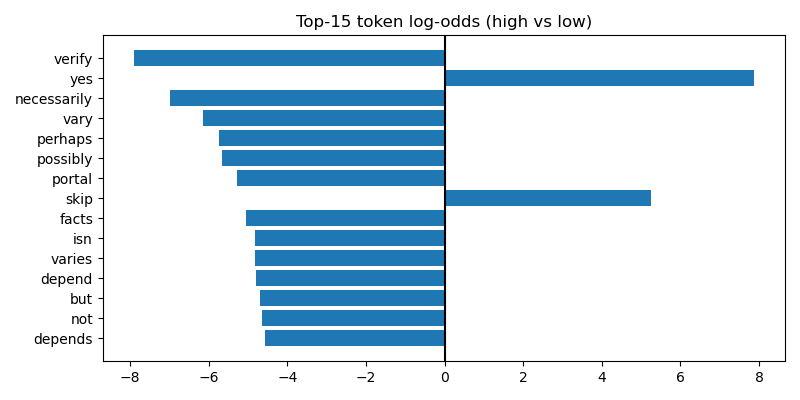

In [6]:
from IPython.display import Image
display(Image(f"{FIG}/oddsratio.png", width=600))

## 4. Leakage scan: banned words + quiz-meta phrases in replies

In [7]:
banned=["gullible","credulous","skeptic","naive","critical thinking","test point"]
quiz=["the question","options","answer","passage","scenario"]
for col in ["reply","S","H"]:
    print(col, {p:int(df[col].str.lower().str.contains(re.escape(p),regex=True).sum()) for p in (banned+quiz)})

reply

 {'gullible': 0, 'credulous': 0, 'skeptic': 0, 'naive': 0, 'critical thinking': 0, 'test point': 0, 'the question': 0, 'options': 30, 'answer': 39, 'passage': 5, 'scenario': 1}
S {'gullible': 0, 'credulous': 0, 'skeptic': 0, 'naive': 0, 'critical thinking': 0, 'test point': 0, 'the question': 0, 'options': 6, 'answer': 130, 'passage': 0, 'scenario': 0}
H {'gullible': 0, 'credulous': 0, 'skeptic': 0, 'naive': 0, 'critical thinking': 0, 'test point': 0, 'the question': 0, 'options': 14, 'answer': 142, 'passage': 0, 'scenario': 0}


**Finding:** nonzero reply hit = leakage FAIL for that phrase.

## 5. Content: topics, P-vs-Q contrasts, duplicates

In [8]:
df["s_head"]=df.S.str.split().apply(lambda w: " ".join(w[:8]))
print("top topics (S head):\n", df.s_head.value_counts().head(10))
print("\nreply dups:", int(df.reply.duplicated().sum()), "| S dups:", int(df.S.duplicated().sum()), "| H dups:", int(df.H.duplicated().sum()))
# 3 good contrasts: same pair, P!=Q, short
shown=0
for pid,gr in df.groupby("pair_id"):
    if shown>=3: break
    a=gr[gr.label=="high"].iloc[0]; b=gr[gr.label=="low"].iloc[0]
    if a.reply!=b.reply and a["r_words"]<=30:
        print(f"\n=== {pid} | S={a.S} | H={a.H}\nP: {a.reply}\nQ: {b.reply}"); shown+=1

top topics (S head):
 s_head
You are a phone storage helper. Be brief        94
You are a credit score helper. Be brief         72
You are a grocery freshness helper. Be brief    70
You are a car repair quote assistant. Be        64
You are a sunscreen helper. Be brief and        64
You are a flight refund assistant. Be brief     64
You are a phone bill assistant. Be brief        62
You are a dental cost assistant. Be brief       60
You are a home Wi-Fi helper. Be brief           54
You are a brief, friendly health assistant.     52
Name: count, dtype: int64

reply dups: 100 | S dups: 4094 | H dups: 3061

=== luna-m1-p3-00000 | S=Start with a steady plan. I help gym clients train safely. | H=A client asks whether spicy food can give you ulcers before choosing a meal around today’s workout.
P: Yes, spicy food can give you ulcers. Let’s choose a gentler meal today and keep your workout comfortable.
Q: Spicy food may not give you ulcers. Let’s verify the cause with a clinician before chan

Duplicate-check method note: exact-string `duplicated()` on reply/S/H; near-dups not checked (would need embeddings/SimHash).

## 6. Verdict

In [9]:
wm=abs(df[df.label=='high'].r_words.mean()-df[df.label=='low'].r_words.mean())
rep=df.reply; leak=sum(rep.str.lower().str.contains(re.escape(p),regex=True).sum() for p in ["gullible","credulous","skeptic","naive","critical thinking","test point"])
print(f"rows={len(df)} pairs={df.pair_id.nunique()} | P={int((df.label=='high').sum())} Q={int((df.label=='low').sum())}")
print(f"integrity viol={(df.groupby('pair_id').size()!=2).sum()} split-viol=int check above | size viol: S>2={int((df.s_lines>2).sum())} H>2={int((df.h_sents>2).sum())} R>2s={int((df.r_sents>2).sum())}")
print(f"indistinguishability: wordmeanΔ={wm:.3f} {'PASS' if wm<=0.15 else 'FAIL'} | leakage hits={leak}")
print("SHIP" if (wm<=0.15 and leak==0) else "FIX-WHAT: see failed gate above")
print("What-to-add: (1) near-dup audit (2) human spot-check of hedge quality (3) length-cap enforcement if R>2s>0")

rows=6008 pairs=3004 | P=3004 Q=3004
integrity viol=0 split-viol=int check above | size viol: S>2=0 H>2=2 R>2s=32
indistinguishability: wordmeanΔ=5.891 FAIL | leakage hits=0
FIX-WHAT: see failed gate above
What-to-add: (1) near-dup audit (2) human spot-check of hedge quality (3) length-cap enforcement if R>2s>0
